In [1]:
#import part
import src.Astar_route as astar
import random
import src.make_map_list as mml
from src.Map_visualize import map_visualize as mapv
from src.Agent import Agent as agent
import src.make_order as mo
from src.visualize_simulation import visualize_simulation as vs
import csv
import numpy as np
import pandas as pd
import time
import os
from IPython.display import clear_output

In [2]:
#config part

num_node = 30 #ノード数
gen_prob = 0.3
deadtime = 100
current_time = 0
order_id_counter = 1
num_agent= 3
attitude = astar.a_star
agents= {}
vehicle_speed =75

ST_PENDING = "PENDING"
ST_ASSIGNED = "ASSIGNED"
ST_COMPLETED = "COMPLETED"

log_filename = "simulation_log_002.csv"

{'0': {'pos': (87, 33), 'edges': [('18', 23), ('7', 75)]}, '1': {'pos': (94, 7), 'edges': [('11', 42), ('5', 67)]}, '2': {'pos': (41, 16), 'edges': [('27', 84), ('26', 8)]}, '3': {'pos': (1, 73), 'edges': [('1', 114), ('23', 75)]}, '4': {'pos': (89, 13), 'edges': [('6', 77), ('0', 20)]}, '5': {'pos': (77, 72), 'edges': [('28', 31), ('20', 54)]}, '6': {'pos': (25, 56), 'edges': [('25', 65), ('28', 28)]}, '7': {'pos': (13, 50), 'edges': [('17', 33), ('18', 77)]}, '8': {'pos': (36, 1), 'edges': [('11', 74), ('23', 21)]}, '9': {'pos': (72, 3), 'edges': [('25', 16), ('13', 74)]}, '10': {'pos': (40, 71), 'edges': [('2', 55), ('4', 75)]}, '11': {'pos': (93, 49), 'edges': [('13', 93), ('3', 95)]}, '12': {'pos': (82, 13), 'edges': [('1', 13), ('17', 70)]}, '13': {'pos': (2, 29), 'edges': [('22', 37), ('28', 55)]}, '14': {'pos': (40, 96), 'edges': [('19', 68), ('4', 96)]}, '15': {'pos': (25, 77), 'edges': [('10', 16), ('13', 53)]}, '16': {'pos': (64, 74), 'edges': [('9', 71), ('11', 38)]}, '17':

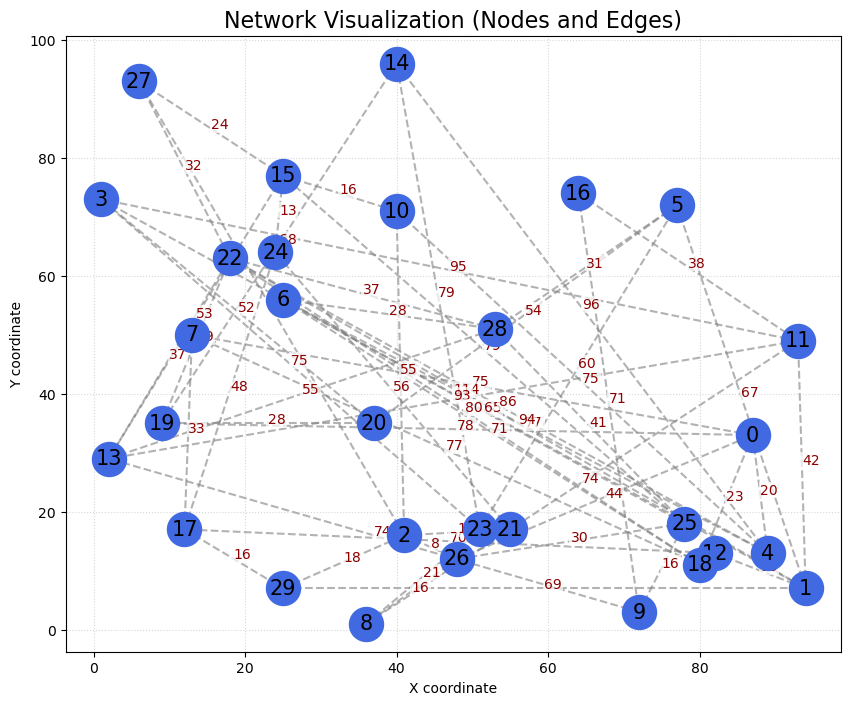

In [3]:
#make map 
edge_map = mml.make_map(num_node=num_node)
print(edge_map)
mapv(edge_map)

In [4]:
#make agent
node_list = list(edge_map.keys())

for i in range(num_agent):
    start_node = random.choice(node_list)
    agent_id = f"AMR_{i}"

    agents[i] = agent(
        agent_id = agent_id,
        start_node= start_node,
        vehicle_speed=vehicle_speed,
        attitude=attitude
    )

#スタートノードが被る可能性があるけど一旦いいや
print("--- エージェント初期化完了 ---")
for idx, ag in agents.items():
    print(f"Index: {idx} | ID: {ag.agent_id} | 現在地ノード: {ag.current_node} | 速度: {ag.speed}")

--- エージェント初期化完了 ---
Index: 0 | ID: AMR_0 | 現在地ノード: 28 | 速度: 75
Index: 1 | ID: AMR_1 | 現在地ノード: 6 | 速度: 75
Index: 2 | ID: AMR_2 | 現在地ノード: 19 | 速度: 75


In [5]:
#simu
active_orders = {}
import math

def get_straight_distance(node_a, node_b, emap):
    pos_a = emap[node_a]["pos"]
    pos_b = emap[node_b]["pos"]
    return math.hypot(pos_a[0] - pos_b[0], pos_a[1] - pos_b[1])


print("シミュレーションを開始します... (Ctrl+C で停止)")
try:
    while True:

        # --- STEP 1: 新しいオーダーの発生 ---
        if np.random.rand() < gen_prob:
            oid = f"ORD_{order_id_counter:05d}"
            # あなたの作成した make_order 関数を呼び出し
            new_ord = mo.make_order(num_node, current_time, deadtime, oid)
            new_ord["origin"] = str(new_ord["origin"])
            new_ord["destination"] = str(new_ord["destination"])
            active_orders[oid] = new_ord
            order_id_counter += 1

        # --- STEP 2: 【変更点】配分マッチング ＆ エージェントの移動 ---

        # 2-1. 距離ベースでのオーダー配分（管制塔のロジック）
        for oid, order in active_orders.items():
            if order["status"] == ST_PENDING:

                best_agent = None
                min_distance = float("inf")

                # 待機中（IDLE）のロボットの中で、荷物位置（origin）に一番近い子を探す
                for ag in agents.values():
                    if ag.status == "IDLE":
                        dist = get_straight_distance(
                            ag.current_node, order["origin"], edge_map
                        )
                        if dist < min_distance:
                            min_distance = dist
                            best_agent = ag

                # 一番近いロボットが見つかったら、仕事を正式に割り当てる
                if best_agent is not None:
                    best_agent.assign_order(order, edge_map)
                    order["status"] = ST_ASSIGNED
                    print(
                        f"🤖 [配分] {best_agent.agent_id} が オーダー {oid} を担当します (距離: {min_distance:.1f}m)"
                    )

        # 2-2. すべてのエージェントの時間を1ステップ進める（移動・到着判定）
        for ag in agents.values():
            ag.update(edge_map)

        # --- STEP 3: 完了したオーダーの回収（メモリ解放 ＆ CSV保存） ---
        completed_ids = [
            oid
            for oid, order in active_orders.items()
            if order["status"] == ST_COMPLETED
        ]

        if completed_ids:
            completed_list = []
            for oid in completed_ids:
                order_data = active_orders.pop(oid)  # 辞書から完全削除
                completed_list.append(order_data)

            # CSVに追記保存
            df_to_save = pd.DataFrame(completed_list)
            df_to_save.to_csv(
                log_filename,
                mode="a",
                header=not os.path.exists(log_filename),
                index=False,
            )

        # --- STEP 4: 定期的なコンソール表示 (10ステップごと) ---
        if current_time % 10 == 0:
            print(
                f"\n⏱️ Time: {current_time}s | 稼働中オーダー: {len(active_orders)}件"
            )
            # ロボットたちの現在の状態を並べて表示
            for ag in agents.values():
                loc = (
                    ag.current_node
                    if ag.next_node is None
                    else f"{ag.current_node}➔{ag.next_node}"
                )
                print(f"  ┗ {ag.agent_id} [位置: {loc:<7} | 状態: {ag.status}]")

        clear_output(wait=True)

        # ② 新しい状態のマップとロボットを描画する
        vs(edge_map, agents, active_orders, current_time)

        current_time += 1
        time.sleep(0.5)  # ループの速度調整（見やすさのため）

except KeyboardInterrupt:
    print("\nシミュレーションを終了しました。")


シミュレーションを終了しました。


In [6]:
print(active_orders)

{'ORD_00001': {'order_id': 'ORD_00001', 'generation_time': 0, 'origin': '21', 'destination': '7', 'deadline': 100, 'status': 'ASSIGNED'}, 'ORD_00002': {'order_id': 'ORD_00002', 'generation_time': 2, 'origin': '15', 'destination': '8', 'deadline': 102, 'status': 'ASSIGNED'}, 'ORD_00004': {'order_id': 'ORD_00004', 'generation_time': 7, 'origin': '12', 'destination': '20', 'deadline': 107, 'status': 'ASSIGNED'}, 'ORD_00005': {'order_id': 'ORD_00005', 'generation_time': 9, 'origin': '16', 'destination': '4', 'deadline': 109, 'status': 'PENDING'}, 'ORD_00006': {'order_id': 'ORD_00006', 'generation_time': 11, 'origin': '23', 'destination': '10', 'deadline': 111, 'status': 'PENDING'}, 'ORD_00007': {'order_id': 'ORD_00007', 'generation_time': 17, 'origin': '17', 'destination': '15', 'deadline': 117, 'status': 'PENDING'}, 'ORD_00008': {'order_id': 'ORD_00008', 'generation_time': 21, 'origin': '7', 'destination': '25', 'deadline': 121, 'status': 'PENDING'}, 'ORD_00009': {'order_id': 'ORD_00009',